# Initial setup

In [ ]:
# prompt: generate the code to change the current working directory to main directory

import os

# Check the current working directory
print(os.getcwd())

# Change the current working directory
os.chdir('/content/drive/MyDrive/Complete Machine Learning/Machine learning/Supervised ML Models') # Write the current working directory as parameter

# Check the current working directory
print(os.getcwd())

# List contents of the main directory (root directory)
!ls

/content/drive/MyDrive/Complete Machine Learning/Machine learning/Supervised ML Models
/content/drive/MyDrive/Complete Machine Learning/Machine learning/Supervised ML Models
'Decision tree.ipynb'   Projects			  winequality-red.csv
 diabetes.csv	       'Random Forest.ipynb'
'Naive bayes.ipynb'    'Simple Linear Regression.ipynb'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create an Dataframe

In [ ]:
dataframe = pd.read_csv('diabetes.csv')
dataframe.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
dataframe.shape

(768, 9)

In [ ]:
dataframe.columns
cols = dataframe.columns
cols

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
dataframe.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
dataframe.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# insight
*   records 768
*   Data imputation is to be done fir 0's in every features
*   Target column: Outcome [0,1] (binary classification task)
*   As there is target column, supervised machine learning algorithm.

# EDA: Exploratory Data analysis

Getting the correlations between the fetures can help us to select the features.  
suppose we have two features F1 and F2 having highly correlation (+ve/-ve) then their impact over the output column is almost same. So we need to select the only one feature i.e. **Feture selection**

In [ ]:
dataframe.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


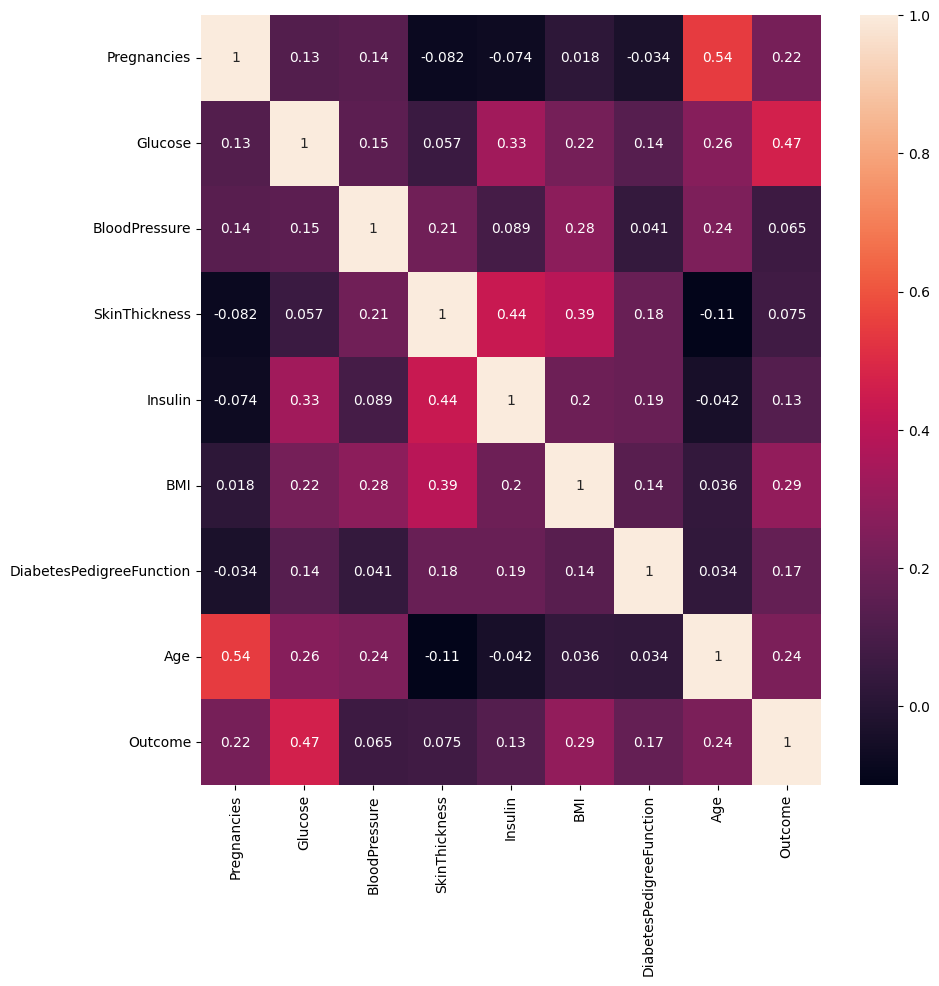

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

plt.figure(figsize=(10,10))
sns.heatmap(dataframe.corr(), annot=True)
plt.show()
# plt.savefig("Heat.jpg")

No high correlation coefficient in this perticular dataset, we can;t remove any features.

## Description of data

In [ ]:
dataframe.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Data Imputation
We need to figure out what is the distribution of our data.
* **symmetric distribution** -> there is no Outlier -> **mean imputation**
* **non-symmetric distribution** -> there is Outlier -> **median imputation**
* **Categorical Data** -> **Mode imputation**

Median is more robust to the outline..

/tmp/ipykernel_2050/3925820562.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe.Pregnancies)


<Axes: xlabel='Pregnancies', ylabel='Density'>

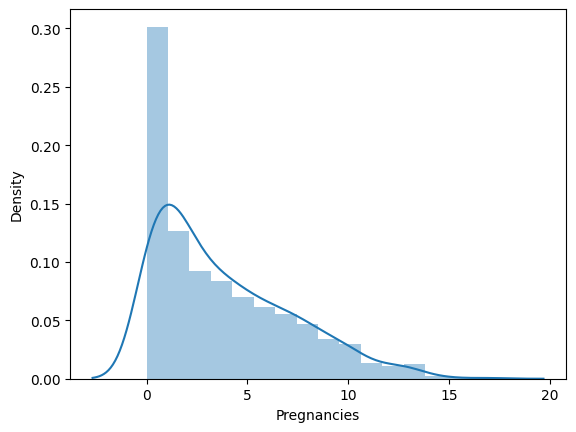

In [ ]:
# Pregnancies Distplot
sns.distplot(dataframe.Pregnancies)
# Median Imputation

/tmp/ipykernel_2050/1806908479.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe.Glucose)


<Axes: xlabel='Glucose', ylabel='Density'>

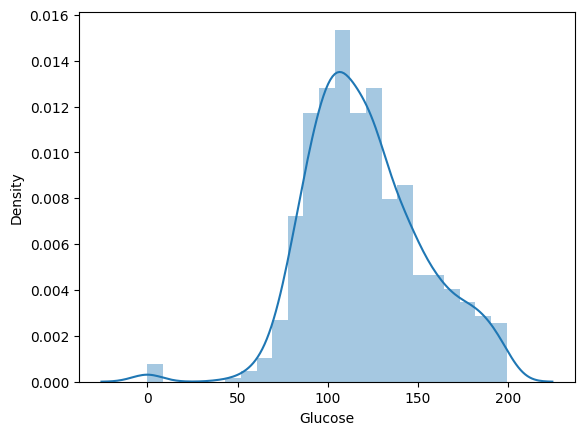

In [ ]:
# Glucose Distplot
sns.distplot(dataframe.Glucose)
# Mean Imputation

/tmp/ipykernel_2050/1647437402.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe.BloodPressure)


<Axes: xlabel='BloodPressure', ylabel='Density'>

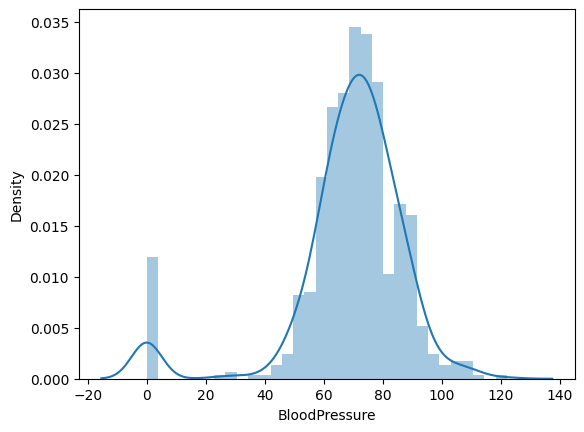

In [ ]:
# BloodPressure Distplot
sns.distplot(dataframe.BloodPressure)
# Mean Imputation

/tmp/ipykernel_2050/849502613.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe.SkinThickness)


<Axes: xlabel='SkinThickness', ylabel='Density'>

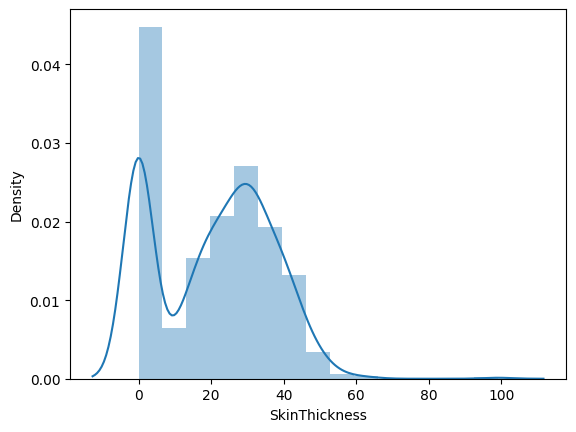

In [ ]:
# SkinThickness Distplot
sns.distplot(dataframe.SkinThickness)
# Median Imputation

/tmp/ipykernel_2050/1852503622.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe.Insulin)


<Axes: xlabel='Insulin', ylabel='Density'>

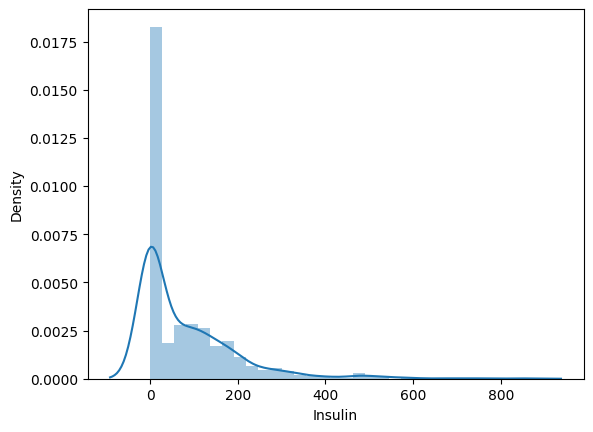

In [ ]:
# Insulin Distplot
sns.distplot(dataframe.Insulin)
# Median Imputation

/tmp/ipykernel_2050/2273391444.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe.BMI)


<Axes: xlabel='BMI', ylabel='Density'>

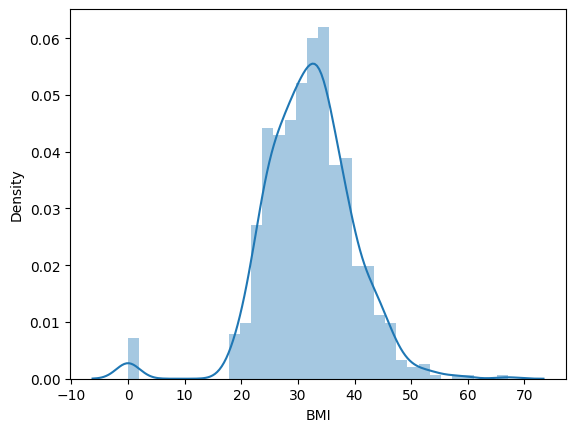

In [ ]:
# BMI Distplot
sns.distplot(dataframe.BMI)
# Mean Imputation

/tmp/ipykernel_2050/2267850378.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe.DiabetesPedigreeFunction)


<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Density'>

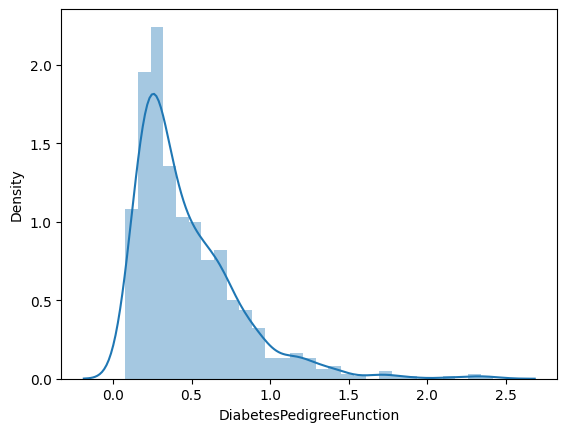

In [ ]:
# DiabetesPedigreeFunction Distplot
sns.distplot(dataframe.DiabetesPedigreeFunction)
# Median Imputation

/tmp/ipykernel_2050/3209949519.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe.Age)


<Axes: xlabel='Age', ylabel='Density'>

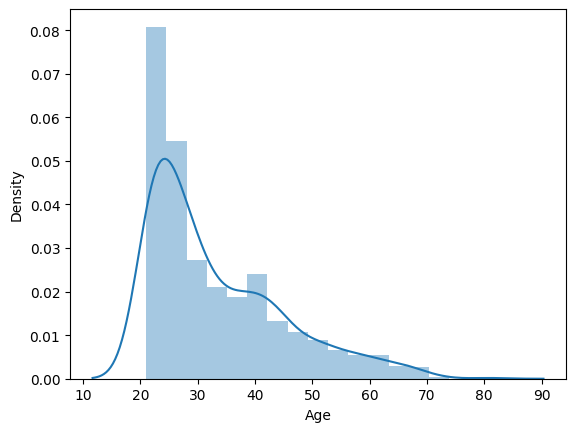

In [ ]:
# Age Distplot
sns.distplot(dataframe.Age)
# Median Imputation

In [ ]:
# Implementing imputaton over them
dataframe['Pregnancies'] = dataframe['Pregnancies'].replace(0, dataframe['Pregnancies'].median())
dataframe['Glucose'] = dataframe['Glucose'].replace(0, dataframe['Glucose'].mean())
dataframe['BloodPressure'] = dataframe['BloodPressure'].replace(0, dataframe['BloodPressure'].mean())
dataframe['SkinThickness'] = dataframe['SkinThickness'].replace(0, dataframe['SkinThickness'].median())
dataframe['Insulin'] = dataframe['Insulin'].replace(0, dataframe['Insulin'].median())
dataframe['BMI'] = dataframe['BMI'].replace(0, dataframe['BMI'].mean())
dataframe['DiabetesPedigreeFunction'] = dataframe['DiabetesPedigreeFunction'].replace(0, dataframe['DiabetesPedigreeFunction'].median())
dataframe['Age'] = dataframe['Age'].replace(0, dataframe['Age'].median())

# Selecting input and output fetures

In [ ]:
# X = imput columns
# Y = Output columns

X = dataframe.drop('Outcome', axis=1)
Y = dataframe['Outcome']

# Outliers Detection - Boxplot

Any value which lies beond upper/lower wisker are outliers.

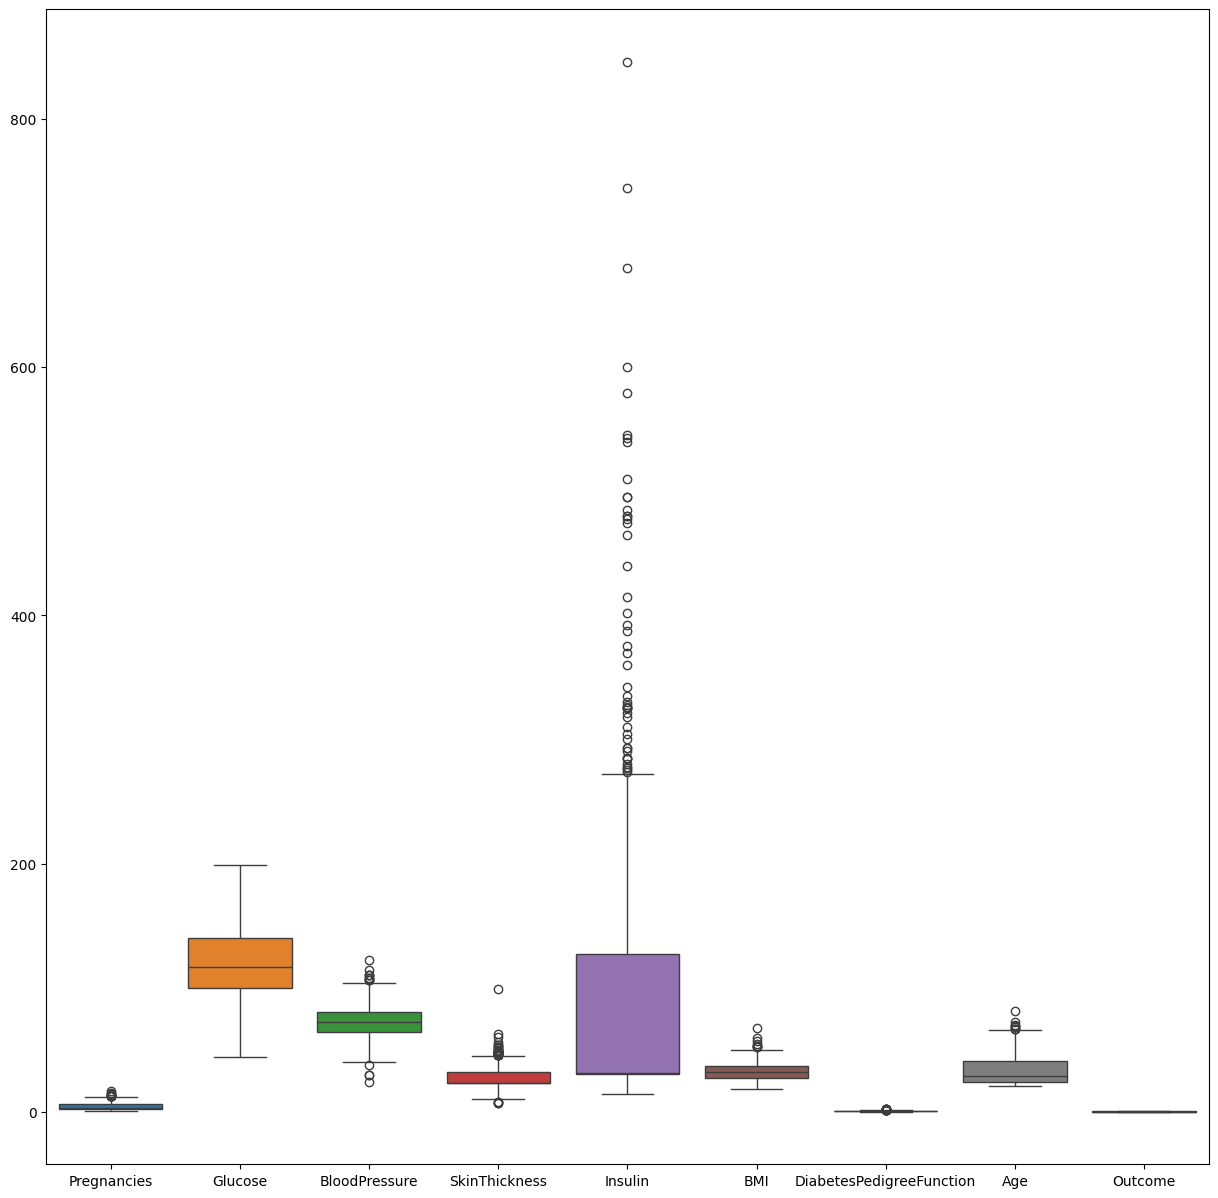

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
sns.boxplot(dataframe, ax = ax)
plt.show()

# Outliers removal -- IQR

In [ ]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for col in cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (X[col] >= lower_bound) & (X[col] <= upper_bound)
mask

,Age
0,True
1,True
2,True
3,True
4,True
...,...
763,True
764,True
765,True
766,True


In [ ]:
# Filter dataset to remove outliers
X_outlier_detection = X[mask]
Y_outlier_detection = Y[mask]

In [ ]:
X_outlier_detection

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35,30.5,33.6,0.627,50
1,1,85.0,66.0,29,30.5,26.6,0.351,31
2,8,183.0,64.0,23,30.5,23.3,0.672,32
3,1,89.0,66.0,23,94.0,28.1,0.167,21
4,3,137.0,40.0,35,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48,180.0,32.9,0.171,63
764,2,122.0,70.0,27,30.5,36.8,0.340,27
765,5,121.0,72.0,23,112.0,26.2,0.245,30
766,1,126.0,60.0,23,30.5,30.1,0.349,47


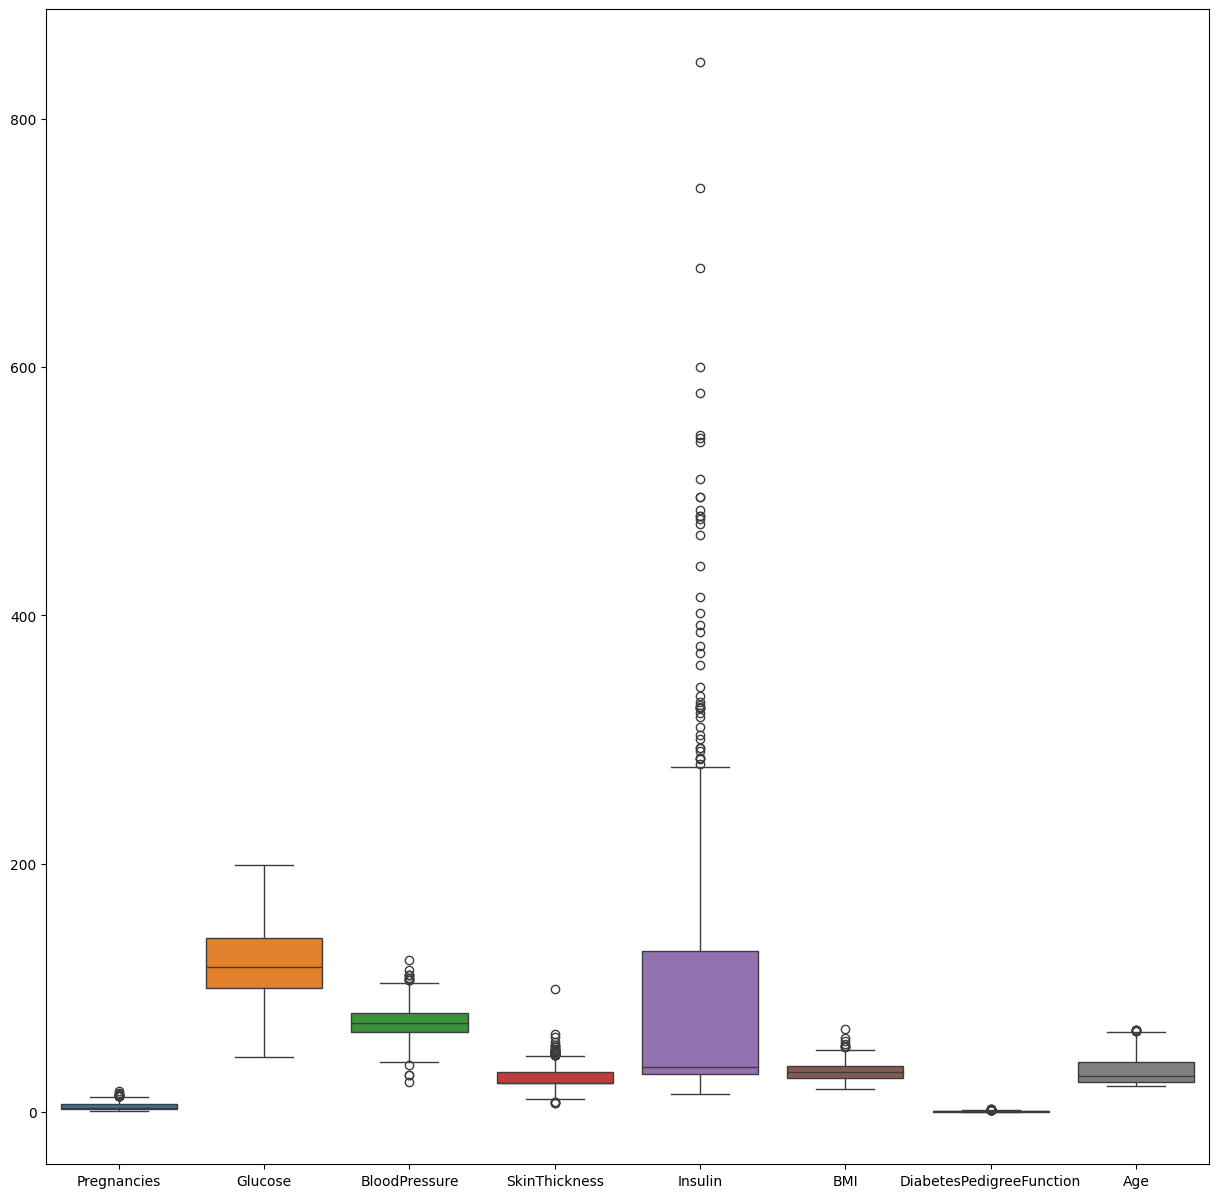

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
sns.boxplot(X_outlier_detection, ax = ax)
plt.show()

# Standardization
convert our data in standered normal form -> Mean = 0, Standard deviation = 1.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_outlier_detection)
X_scaled = pd.DataFrame(X_scaled, columns=cols)

X_scaled.reset_index(drop=True, inplace=True)
Y_outlier_detection.reset_index(drop=True, inplace=True)

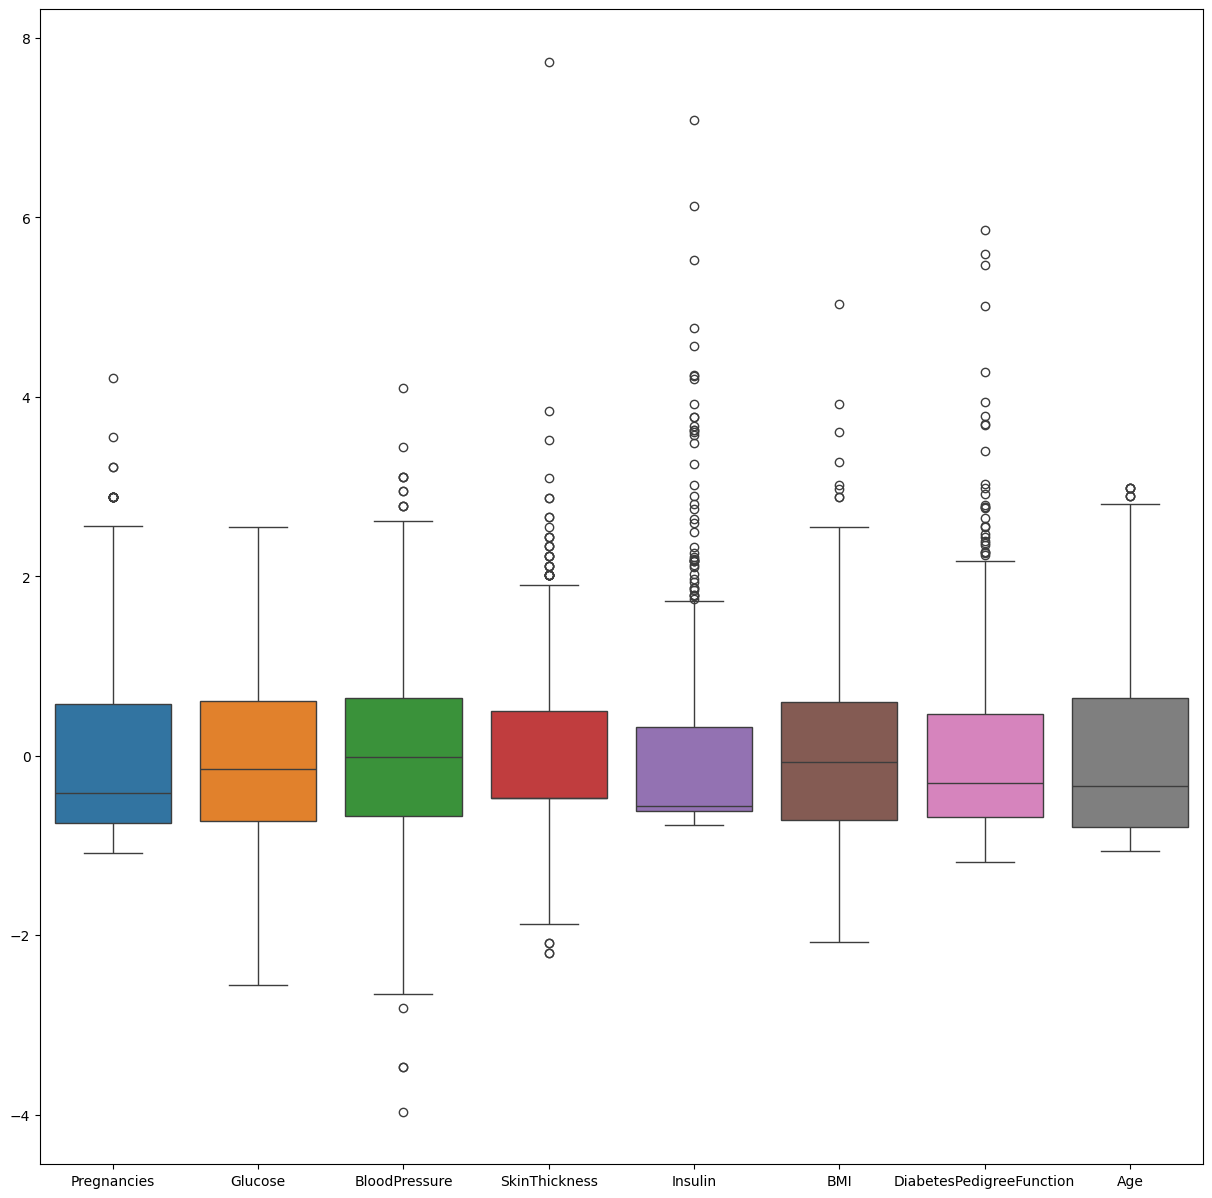

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
sns.boxplot(X_scaled, ax = ax)
plt.show()

In [ ]:
X_scaled = pd.DataFrame(X_scaled)
X_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02
mean,1.029772e-16,-3.978665e-17,-3.042508e-17,-1.509552e-16,-4.329724e-17,5.546727e-16,4.914821e-17,1.591466e-16
std,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00
min,-1.079800e+00,-2.558042e+00,-3.968588e+00,-2.200901e+00,-7.684941e-01,-2.081038e+00,-1.183313e+00,-1.062953e+00
25%,-7.491956e-01,-7.286101e-01,-6.755847e-01,-4.729631e-01,-6.126688e-01,-7.125819e-01,-6.852739e-01,-7.928253e-01
50%,-4.185912e-01,-1.517621e-01,-1.698412e-02,-4.729631e-01,-5.607270e-01,-7.202795e-02,-3.045975e-01,-3.426125e-01
75%,5.732217e-01,6.063810e-01,6.416165e-01,4.990017e-01,3.222827e-01,5.976421e-01,4.627740e-01,6.478556e-01
max,4.209869e+00,2.551183e+00,4.099270e+00,7.734740e+00,7.088876e+00,5.037846e+00,5.864467e+00,2.988962e+00


In [ ]:
Y_outlier_detection.value_counts()

,count
Outcome,
0,493
1,266


# Outliers removal

In [ ]:
print("Orignal shape of dataframe:", dataframe.shape)
print("After removal of outlier through IQR:", X_scaled.shape)

Orignal shape of dataframe: (768, 9)
After removal of outlier through IQR: (759, 8)


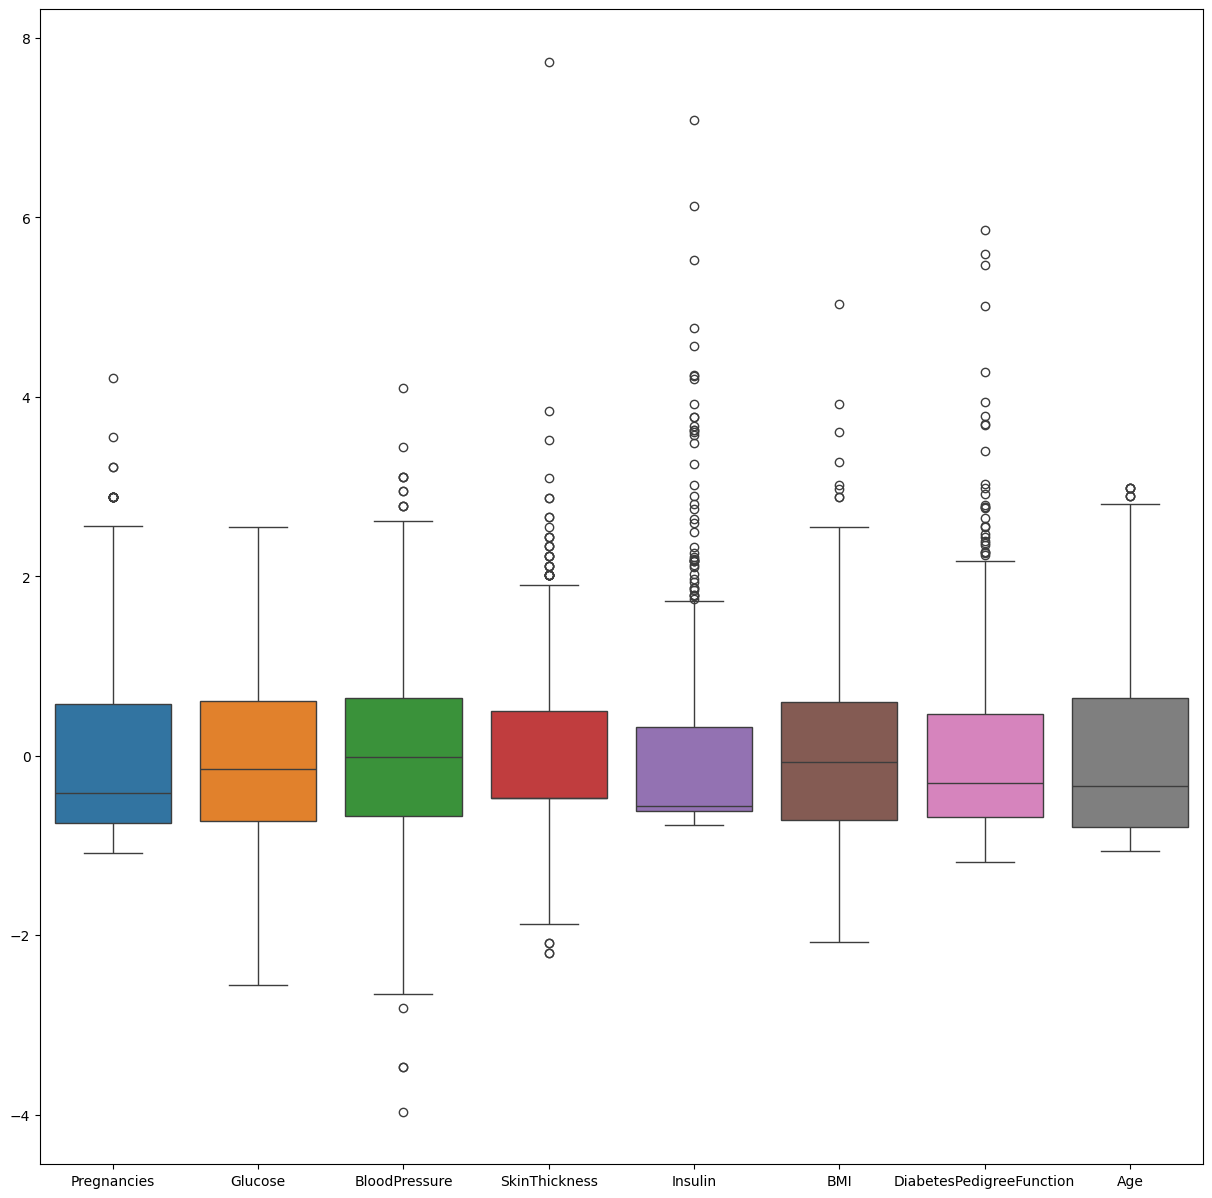

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
sns.boxplot(X_scaled, ax = ax)
plt.show()

### Insulin

In [ ]:
q = X_scaled['Insulin'].quantile(.9973)
mask = X_scaled['Insulin'] < q
dataNew = X_scaled[mask]
Y_outlier_detection = Y_outlier_detection[mask]

dataNew = dataNew.reset_index(drop=True)
Y_outlier_detection = Y_outlier_detection.reset_index(drop=True)

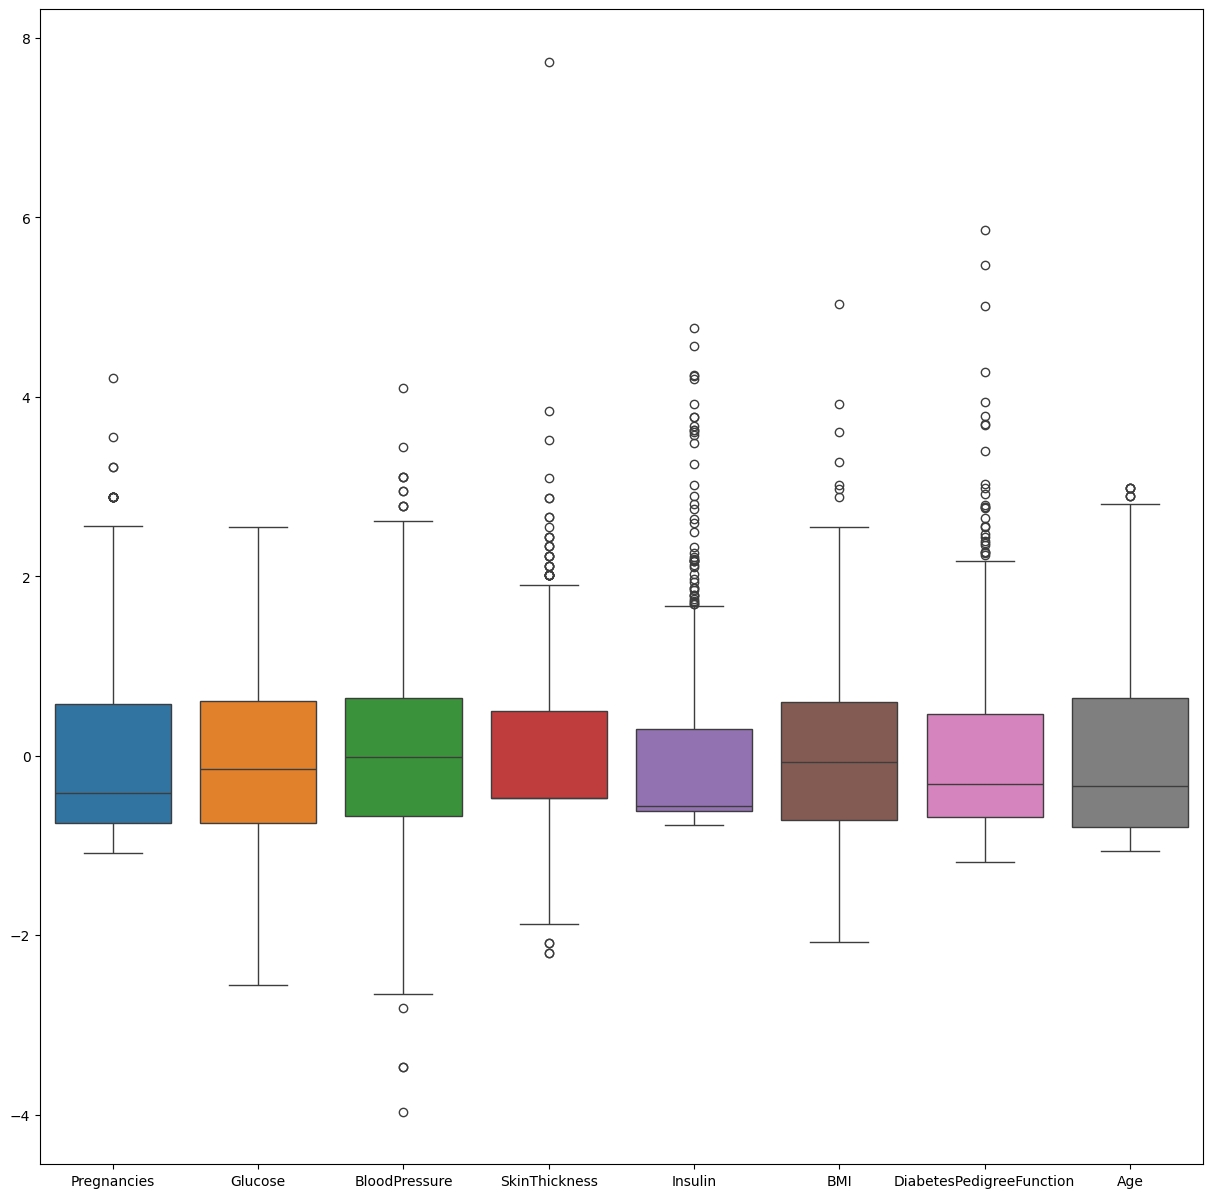

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
sns.boxplot(dataNew, ax = ax)
plt.show()

In [ ]:
print("Orignal shape of dataframe:", dataframe.shape)
print("After removal of outlier through IQR:", X_scaled.shape)
print("After removal of outlier through Quantization of <Insulin>: ", dataNew.shape)

Orignal shape of dataframe: (768, 9)
After removal of outlier through IQR: (759, 8)
After removal of outlier through Quantization of <Insulin>:  (756, 8)


### DiabetesPedigreeFunction


In [ ]:
q = dataNew['DiabetesPedigreeFunction'].quantile(.9973)
mask = dataNew['DiabetesPedigreeFunction'] < q
dataNewfun = dataNew[mask]
Y_outlier_detection = Y_outlier_detection[mask]

dataNewfun = dataNewfun.reset_index(drop=True)
Y_outlier_detection = Y_outlier_detection.reset_index(drop=True)

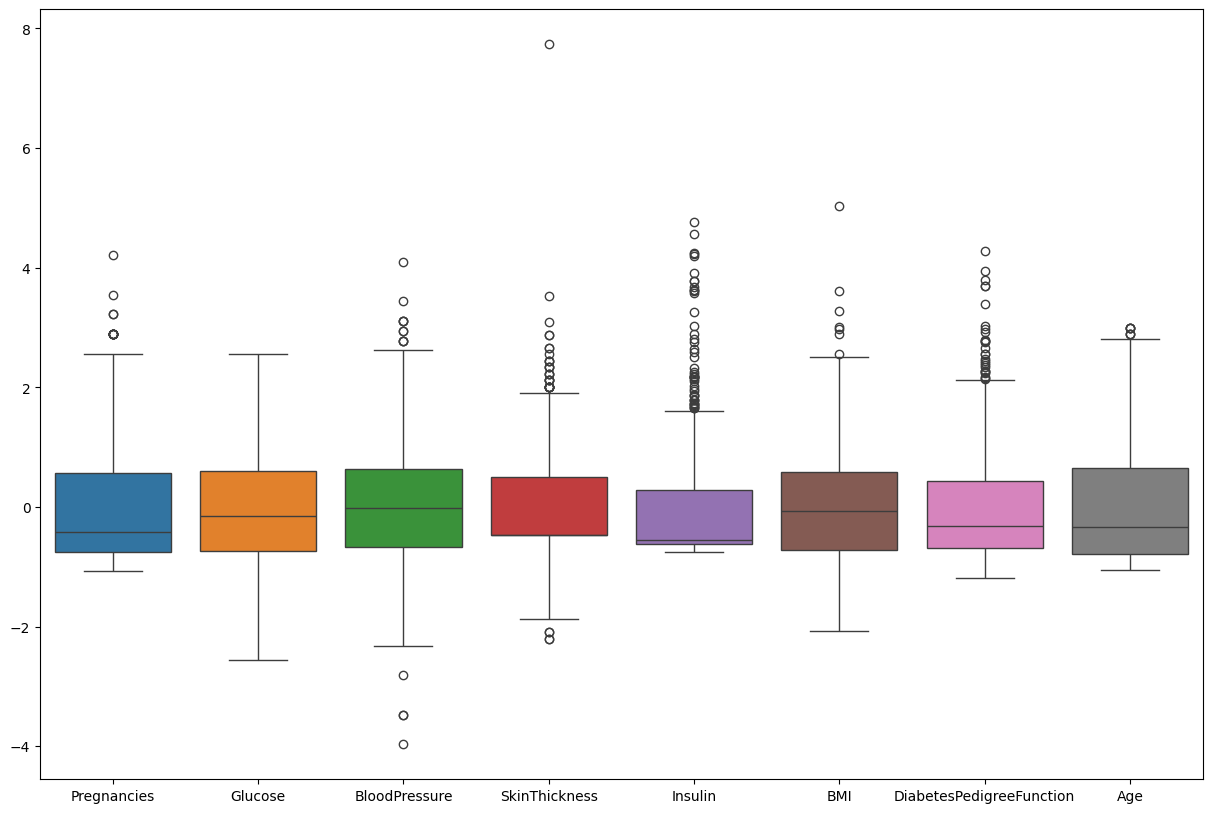

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(dataNewfun, ax = ax)
plt.show()

In [ ]:
print("Orignal shape of dataframe:", dataframe.shape)
print("After removal of outlier through IQR:", X_scaled.shape)
print("After removal of outlier through Quantization of <Insulin>: ", dataNew.shape)
print("After removal of outlier through Quantization of <DiabetesPedigreeFunction>: ", dataNewfun.shape)

Orignal shape of dataframe: (768, 9)
After removal of outlier through IQR: (759, 8)
After removal of outlier through Quantization of <Insulin>:  (756, 8)
After removal of outlier through Quantization of <DiabetesPedigreeFunction>:  (753, 8)


### SkinThickness

In [ ]:
q = dataNewfun['SkinThickness'].quantile(.9973)
mask = dataNewfun['SkinThickness'] < q
dataNewskin = dataNewfun[mask]
Y_outlier_detection = Y_outlier_detection[mask]

dataNewskin = dataNewskin.reset_index(drop=True)
Y_outlier_detection = Y_outlier_detection.reset_index(drop=True)

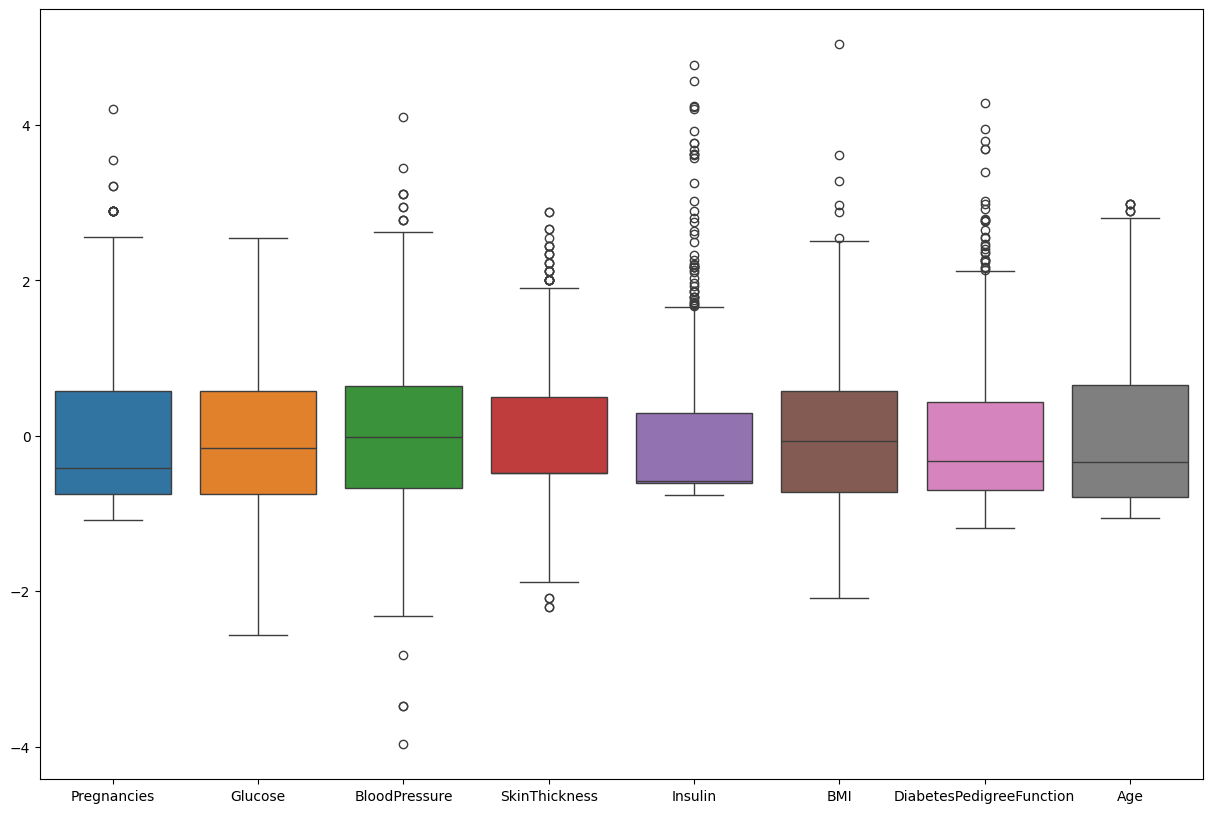

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(dataNewskin, ax = ax)
plt.show()
# plt.savefig("boxplot.jpg")

In [ ]:
print("Orignal shape of dataframe:", dataframe.shape)
print("After removal of outlier through IQR:", X_scaled.shape)
print("After removal of outlier through Quantization of <Insulin>: ", dataNew.shape)
print("After removal of outlier through Quantization of <DiabetesPedigreeFunction>: ", dataNewfun.shape)
print("After removal of outlier through Quantization of <SkinThickness>: ", dataNewskin.shape)

Orignal shape of dataframe: (768, 9)
After removal of outlier through IQR: (759, 8)
After removal of outlier through Quantization of <Insulin>:  (756, 8)
After removal of outlier through Quantization of <DiabetesPedigreeFunction>:  (753, 8)
After removal of outlier through Quantization of <SkinThickness>:  (750, 8)


# Model training

In [ ]:
Y_outlier_detection

,Outcome
0,1
1,0
2,1
3,0
4,0
...,...
745,0
746,0
747,0
748,1


## Train-test split
[Sklearn train-tesst split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(dataNewskin, Y_outlier_detection, test_size=0.33, random_state=42)

In [ ]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((502, 8), (248, 8), (502,), (248,))

In [ ]:
Y_train.value_counts(), dataframe['Outcome'].value_counts()

(Outcome
 0    331
 1    171
 Name: count, dtype: int64,
 Outcome
 0    500
 1    268
 Name: count, dtype: int64)

## Handling Imbalanced Data
* **Oversampling:** Take Minority Class and increase that number to the majority class
* **Undersampling**: Take Majority class and decrease that number to the minority class
* **SMOTE**: Generate Synthetic data and increase the number of samples to the majority class

### **SMOTE Technique**

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

# Check resampled class distribution
print("\nResampled class distribution:")
print(pd.Series(Y_train_smote).value_counts())


Resampled class distribution:
Outcome
0    331
1    331
Name: count, dtype: int64


# Implementation of Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
model_gaussian = GaussianNB()
model_gaussian.fit(X_train_smote, Y_train_smote)

GaussianNB()

In [ ]:
y_pred = model_gaussian.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0])

## Model evaluation
Healthcare domain : Recall is much importatn

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy Score")
model_gaussian.score(X_test, Y_test)

Accuracy Score


0.7580645161290323

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
target_names = ['Non-Diabetic', 'Diabetic']
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred, target_names=target_names))

Confusion Matrix:
[[127  32]
 [ 28  61]]

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.80      0.81       159
    Diabetic       0.66      0.69      0.67        89

    accuracy                           0.76       248
   macro avg       0.74      0.74      0.74       248
weighted avg       0.76      0.76      0.76       248

